In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
@load "combined_dfs.jld2" combined_dfs
@load "metrics_combined.jld2" metrics_combined
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

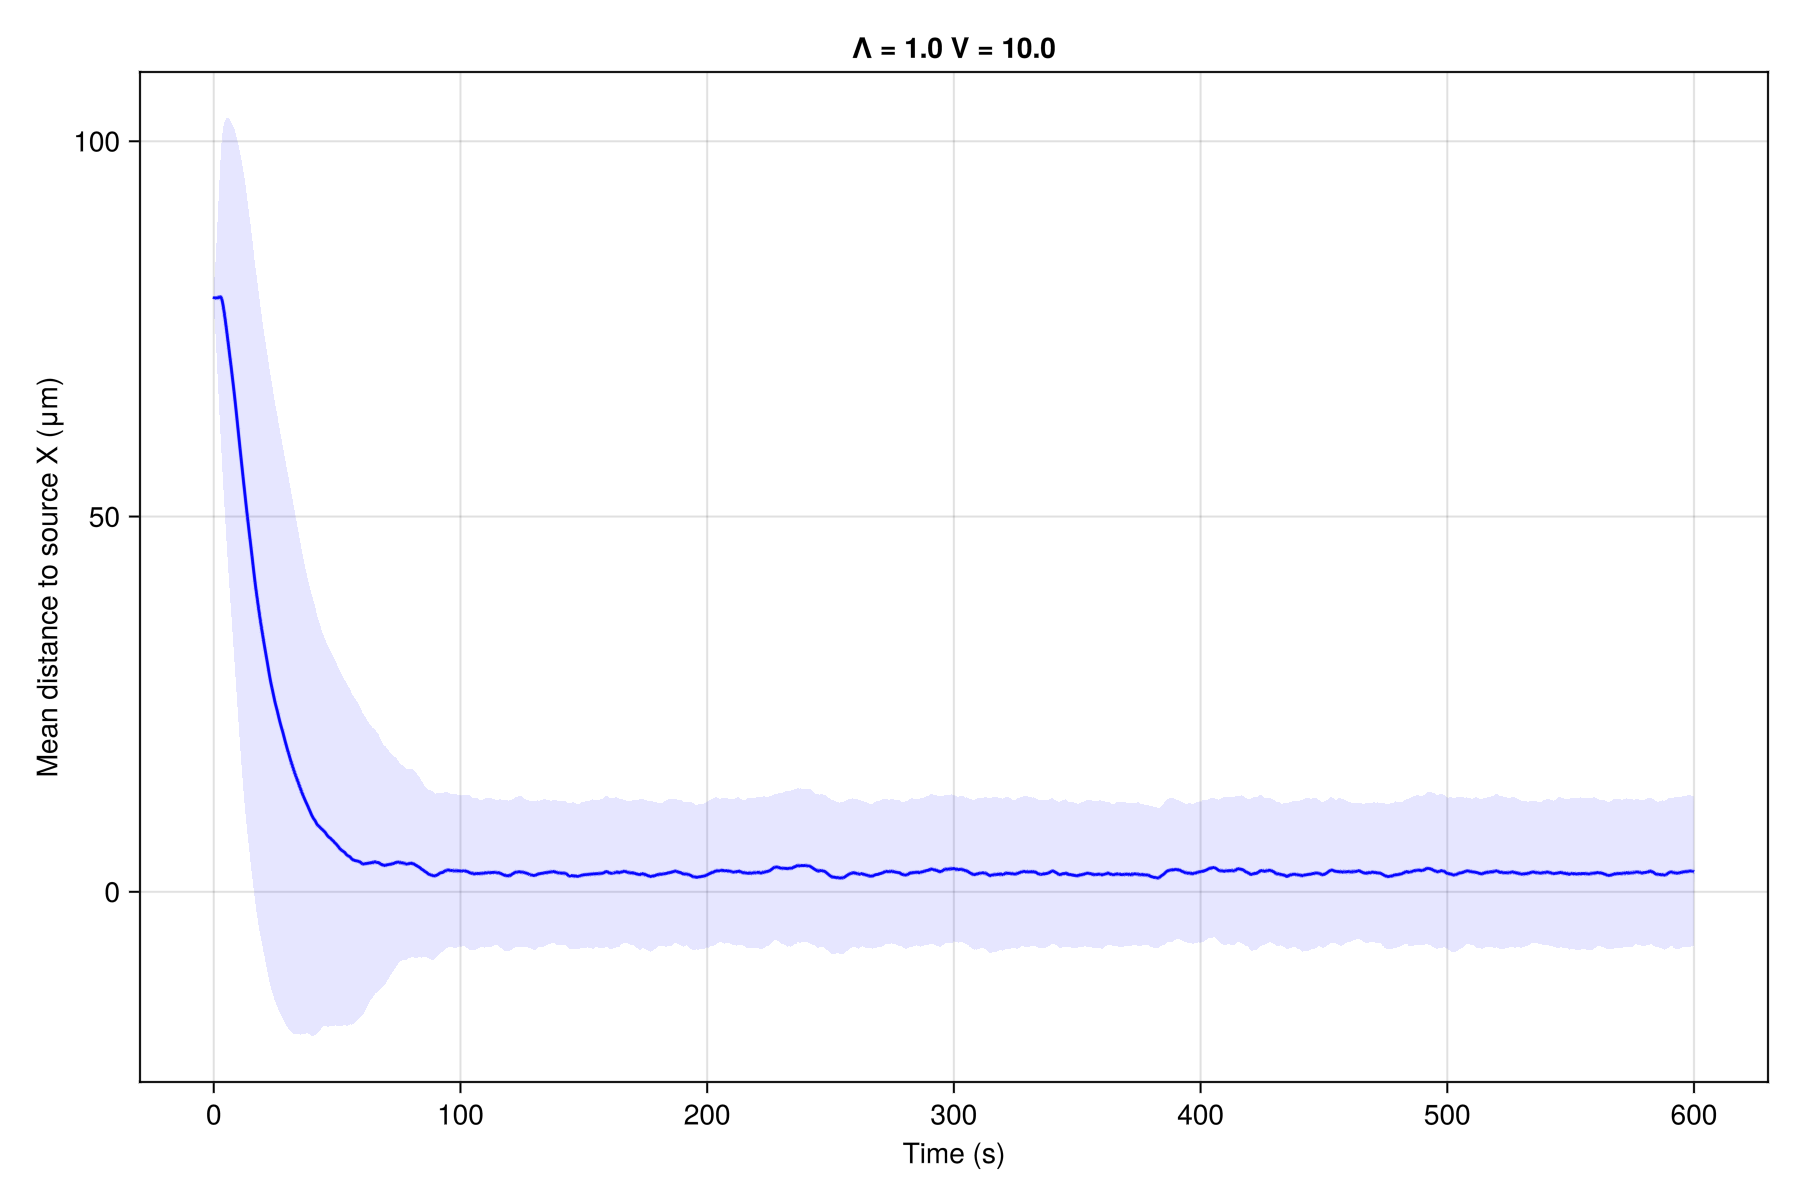

In [7]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "Λ = 1.0 V = 10.0", xlabel = "Time (s)", ylabel = "Mean distance to source X (μm)")
df = combined_dfs[(10.0, 1.0)]
grouped = groupby(df, :step)
mean_x = Float64[]
std_x = Float64[]
for i in 1:length(grouped)
    data = grouped[i]
    x = mean(data.x)
    push!(mean_x, x)
    push!(std_x, std(data.x))
end
time = (1:6000)*0.1
lines!(ax, time, mean_x, color = :blue)
band!(ax, time, mean_x .- std_x, mean_x .+ std_x, color = (:blue, 0.1))

fig

In [8]:
save("Plots/Fixed_source_model/Presentation_meandist.png", fig)

In [9]:
field_merge = innerjoin(metrics_combined, dc_delta, on = [:v, :lambda])

Row,v,lambda,mu_x,mu_y,sigma_x,sigma_y,k_x,k_y,Dc,delta
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,5.0,0.25,2.59492,2.67258,8.09596,7.89805,0.00137991,0.00138897,40.0,0.01
2,5.0,0.5,2.36836,2.42104,6.5484,6.50722,0.00252474,0.00246432,20.0,0.02
3,5.0,0.75,2.54192,2.5562,6.05206,6.1209,0.00320385,0.00321971,13.33,0.03
4,5.0,1.0,2.89775,2.8263,5.9946,5.96359,0.00349954,0.00365125,10.0,0.04
5,5.0,2.0,4.35303,4.25107,6.3092,6.34025,0.00388497,0.00382129,5.0,0.08
6,5.0,3.0,5.09385,5.03858,6.39762,6.44408,0.00364838,0.00366495,3.33333,0.12
7,5.0,4.0,5.09672,5.08283,6.22925,6.19946,0.00344543,0.00382214,2.5,0.16
8,5.0,5.0,4.86336,4.82832,7.05832,6.82974,0.00404968,0.00352136,2.0,0.2
9,5.0,6.0,4.67125,4.67106,8.08399,7.55588,0.00340852,0.00426279,1.66667,0.24


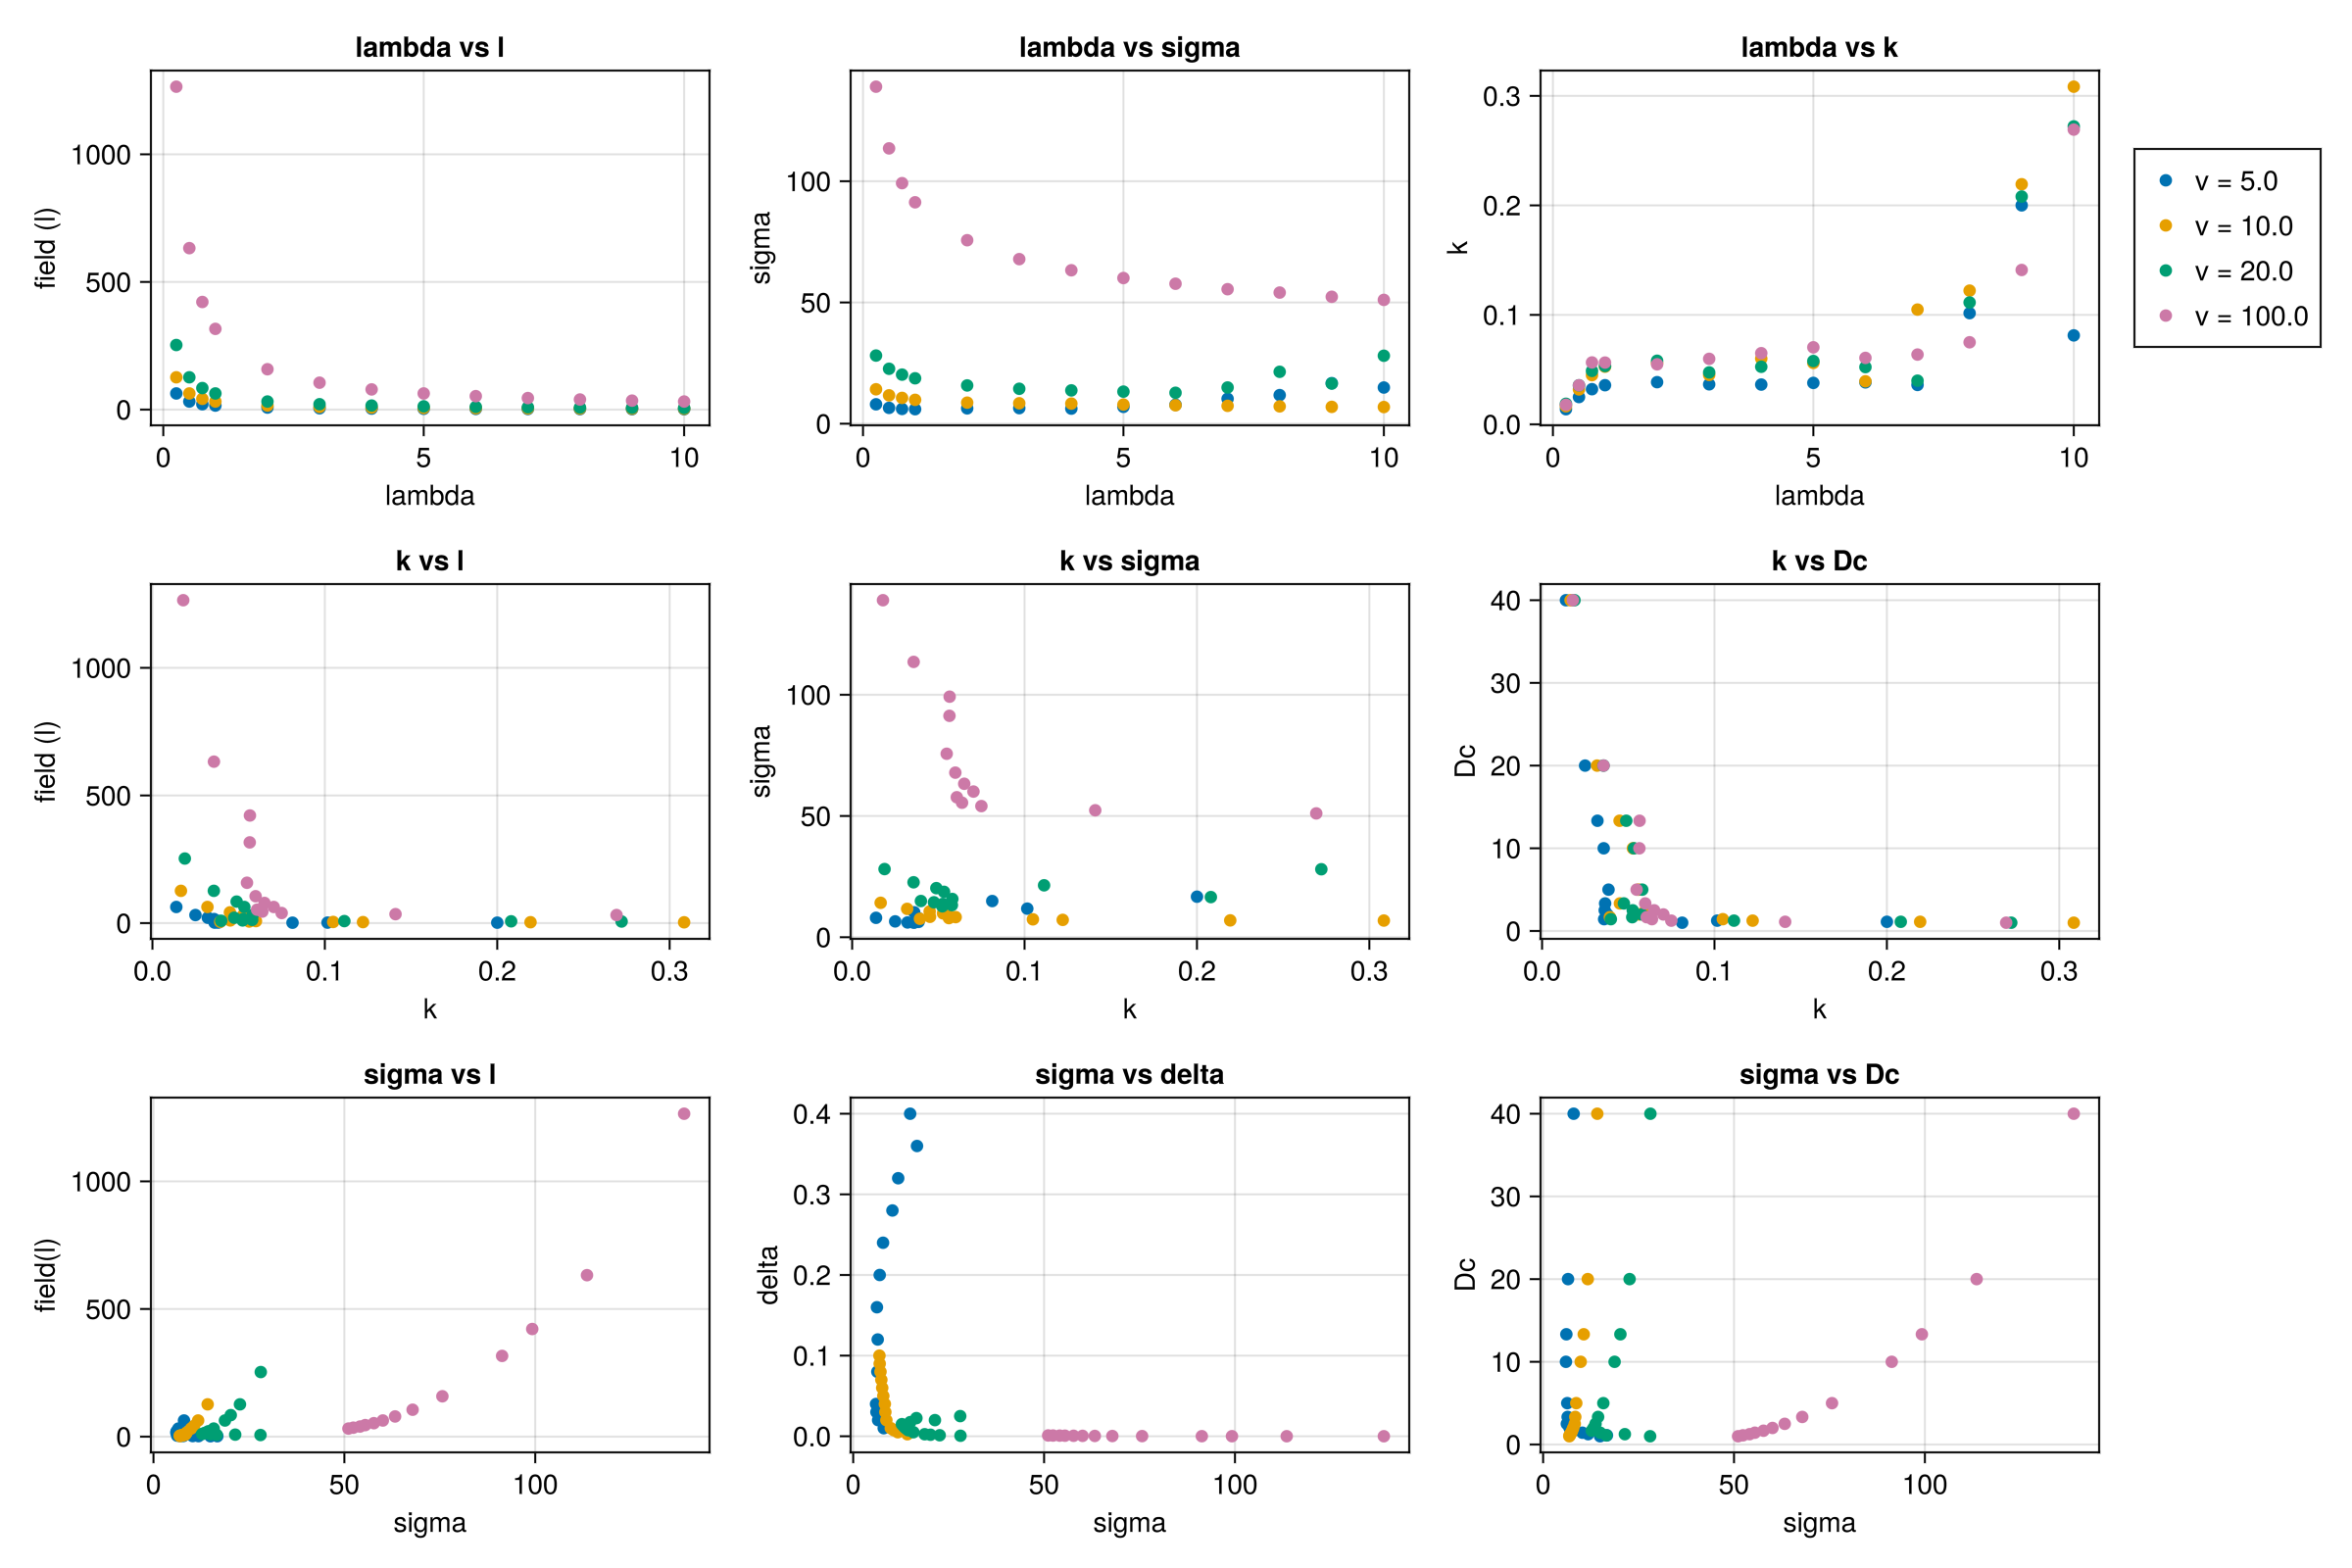

In [34]:
lambda = field_merge.lambda
sigma = (field_merge.sigma_x .+ field_merge.sigma_y) ./ 2
k     = ((field_merge.k_x .+ field_merge.k_y) ./ 2)*10
vvals = field_merge.v

Dc = field_merge.Dc
delta = field_merge.delta
l = sqrt.(Dc ./ delta)

D = sigma .* sqrt.(2 .* k)

fig = Figure(size = (1200, 800))

ax1 = Axis(fig[1, 1],
    xlabel = "lambda",
    ylabel = "field (l)",
    title = "lambda vs l"
)

ax2 = Axis(fig[1, 2],
    xlabel = "lambda",
    ylabel = "sigma",
    title = "lambda vs sigma"
)

ax3 = Axis(fig[1, 3],
    xlabel = "lambda",
    ylabel = "k",
    title = "lambda vs k"
)

ax4 = Axis(fig[2,1],
    xlabel = "k",
    ylabel = "field (l)",
    title = "k vs l"
)

ax5 = Axis(fig[2,2],
    xlabel = "k",
    ylabel = "sigma",
    title = "k vs sigma"
)

ax6 = Axis(fig[2,3],
    xlabel = "k",
    ylabel = "Dc",
    title = "k vs Dc"
)

ax7 = Axis(fig[3,1],
    xlabel = "sigma",
    ylabel = "field(l)",
    title = "sigma vs l"
)

ax8 = Axis(fig[3,2],
    xlabel = "sigma",
    ylabel = "delta",
    title = "sigma vs delta"
)

ax9 = Axis(fig[3,3],
    xlabel = "sigma",
    ylabel = "Dc",
    title = "sigma vs Dc"
)
# unique velocities
unique_v = [5.0, 10.0, 20.0, 100.0]

# choose a color palette
colors = Makie.wong_colors()

for (i, v) in enumerate(unique_v)

    idx = findall(==(v), vvals)

    c = colors[i]

    scatter!(ax1, lambda[idx], l[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax2, lambda[idx], sigma[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax3, lambda[idx], k[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax4, k[idx], l[idx],
        color = c,
        label = "v = $v"
    )  

    scatter!(ax5, k[idx], sigma[idx],
        color = c,
        label = "v = $v"
    ) 

    scatter!(ax6, k[idx], Dc[idx],
        color = c,
        label = "v = $v"
    ) 

    scatter!(ax7, sigma[idx], l[idx],
        color = c,
        label = "v = $v"
    ) 

    scatter!(ax8, sigma[idx], delta[idx],
        color = c,
        label = "v = $v"
    ) 

    scatter!(ax9, sigma[idx], Dc[idx],
        color = c,
        label = "v = $v"
    ) 
end

leg = Legend(fig[1,4], ax1)

fig

In [35]:
save("Plots/Fixed_source_model/presentacio_parameters.png", fig)

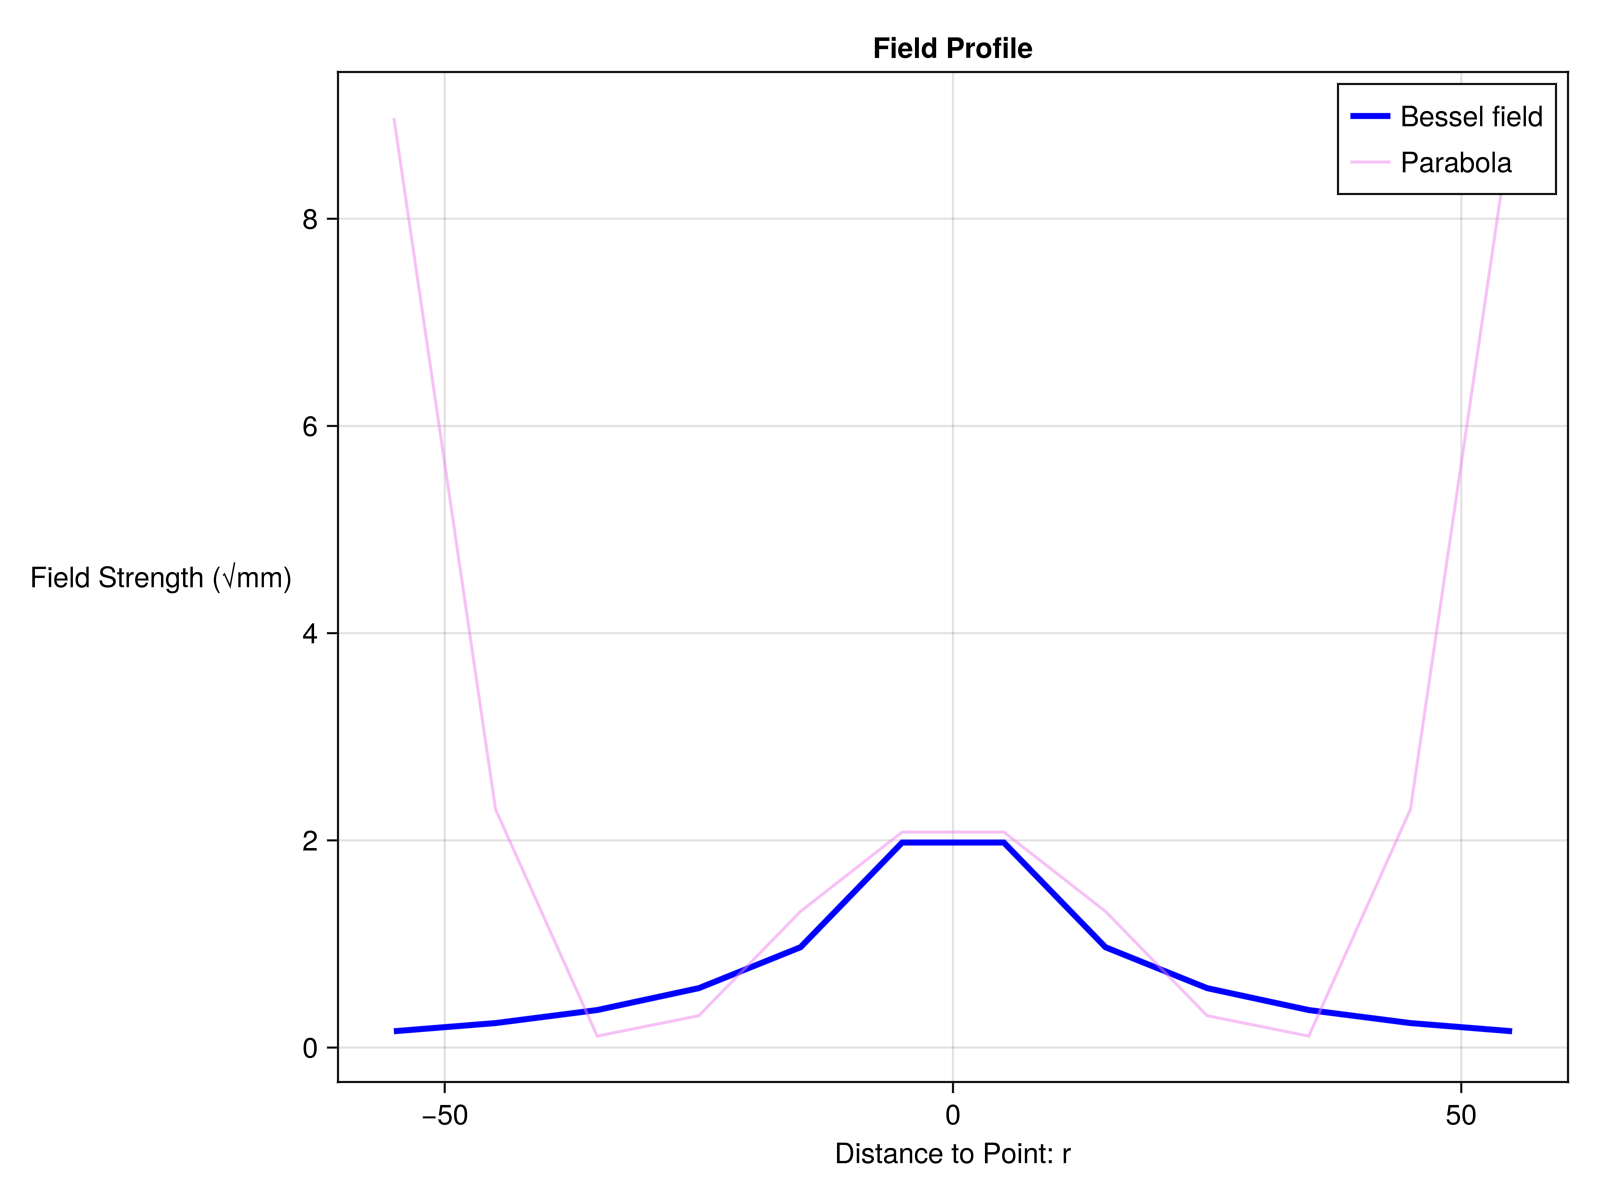

In [48]:
# --- 1. CONFIGURATION ---
mm_factor = 1.0
Dc = 10.0
delta = 0.01
ll = sqrt(Dc/delta)        # Effective length scale (l_eff)
r_max = 55        # Maximum distance to plot (e.g., 5 * ll)

# Generate distance vector (x-axis)
# Start at 0.01 to avoid the singularity at r=0 (K0(0) -> Inf)
# r = LinRange(-55, r_max, 10) 
x = -55:10:55
# x = -100:10:100

# --- 2. CALCULATION ---
# Calculate m = 1.0 * K0(r / ll)
# besselk(0, x) is the modified Bessel function of the second kind, order 0
m_vals = mm_factor .* besselk.(0, abs.(x) ./ ll)

# Calculate the square root
# Ensure we don't take sqrt of negative numbers (K0 is positive for r>0)
sqrt_m_vals = sqrt.(m_vals)

# --- 3. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Field Profile",
          xlabel = "Distance to Point: r",
          ylabel = "Field Strength (√mm)",
          ylabelrotation = 0)

# Plot the line
lines!(ax, x, m_vals, 
       color = :blue, 
       linewidth = 3, 
       label = "Bessel field")
# h = 1.0          # Peak concentration
# b = ll      # Width of the parabola

# y = h .* (1 .- (x.^2 ./b^2.1))
# y = h .* (1 .-(x.^2 ./ll .^2*2))

b = 26
c = ll
y = ((x .^2 .- c .^2) ./b .^2) .^2
# h = 0.001
# c = ll
# b = 0.6

y1 = h .* (1 .+ ((x .- c).^2)/b .^2)
y2 = h .* (1 .+ ((x .+ c).^2)/b .^2)



# lines!(ax, x, y)

# a=2*ll
# y1= ((x).-a).^2 
# y2= ((x).+a).^2 
lines!(ax, x, y, label = "Parabola", color = (:violet, 0.5))
# lines!(ax, x, y1, label = "Parabola 1", color = (:violet, 0.5))
# lines!(ax, x, y2, label = "Parabola 2", color = (:pink, 0.5))


# slope_x, intercept_x = linear_fit(x, sqrt_m_vals)
# fitted_line_x = [intercept_x + slope_x * t for t in r]
# lines!(ax, x, fitted_line_x, label = "$(round(slope_x, digits = 4))", color = :red, linestyle = :dash)
# ylims!(ax, 0, 7)
# xlims!(ax, -100, 100)


# Add legend
axislegend(ax, position = :rt)

# Display the figure
fig

In [49]:
save("Plots/Fixed_source_model/presentation_approximation_parabole_wells.png", fig)